### This notebook provides a focused place for analysis and supplementary materials (such as plots) meant to aid the Findings and Discussions sections of the paper.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
from rich import print
import os
import ast
from dotenv import load_dotenv
from openai import AzureOpenAI
from sklearn.metrics.pairwise import cosine_similarity

# Dataset Characteristics

## Dataset A

In [3]:
dataset_a_dimensions = pd.DataFrame({
    "#": ["1", "2", "3", "4", "5", "6", "7", "8",
          "9†", "10*", "11*", "12*", "13**",
          "14", "15", "16", "17", "18", "19", "20", "21"],
    "Topic": [
        "shelter",
        "safety-protection",
        "safety-protection",
        "health-wellbeing",
        "health-wellbeing",
        "shelter",
        "shelter",
        "shelter; safety-protection",
        "food-clothing",
        "safety-protection",
        "shelter",
        "safety-protection",
        "health-wellbeing",
        "food-clothing",
        "health-wellbeing",
        "safety-protection",
        "safety-protection",
        "shelter; health-wellbeing",
        "food-clothing",
        "food-clothing; safety-protection",
        "food-clothing",
    ],
    "Emotion": [
        "fear", "fear", "fear", "despair", "neutrality", "fatigue", "fatigue", "fear",
        "neutrality", "despair", "frustration", "neutrality", "frustration",
        "despair", "despair", "despair", "frustration", "fatigue", "neutrality", "fear", "fear",
    ],
    "Complexity": [
        "simple", "simple", "simple", "simple", "simple", "simple", "simple", "complex",
        "simple", "non-question", "simple", "simple", "simple",
        "simple", "complex", "complex", "complex", "complex", "unclear", "complex", "complex",
    ],
    "User profile": [
        "undocumented", "—", "undocumented", "undocumented", "—", "—", "asylum seeker",
        "residence permit / Dutch nationality",
        "residence permit / Dutch nationality", "—", "—", "EU labour migrant", "undocumented",
        "—", "undocumented", "residence permit / Dutch nationality", "undocumented", "—",
        "—", "undocumented", "undocumented",
    ],
})

print(dataset_a_dimensions.to_string(index=False))

#                            Topic     Emotion   Complexity                         User profile
   1                          shelter        fear       simple                         undocumented
   2                safety-protection        fear       simple                                    —
   3                safety-protection        fear       simple                         undocumented
   4                 health-wellbeing     despair       simple                         undocumented
   5                 health-wellbeing  neutrality       simple                                    —
   6                          shelter     fatigue       simple                                    —
   7                          shelter     fatigue       simple                        asylum seeker
   8       shelter; safety-protection        fear      complex residence permit / Dutch nationality
  9†                    food-clothing  neutrality       simple residence permit / Dutch nationality
 10*                safety-protection     despair non-question                                    —
 11*                          shelter frustration       simple                                    —
 12*                safety-protection  neutrality       simple                    EU labour migrant
13**                 health-wellbeing frustration       simple                         undocumented
  14                    food-clothing     despair       simple                                    —
  15                 health-wellbeing     despair      complex                         undocumented
  16                safety-protection     despair      complex residence permit / Dutch nationality
  17                safety-protection frustration      complex                         undocumented
  18        shelter; health-wellbeing     fatigue      complex                                    —
  19                    food-clothing  neutrality      unclear                                    —
  20 food-clothing; safety-protection        fear      complex                         undocumented
  21                    food-clothing        fear      complex                         undocumented

### Frequency count for question-forming matrix dimensions

In [4]:
# frequency of values
for col in ["Topic", "Emotion", "Complexity", "User profile"]:
    print(f"\n--- {col} ---")
    print(dataset_a_dimensions[col].value_counts())

--- Topic ---

Topic
safety-protection                   6
shelter                             4
health-wellbeing                    4
food-clothing                       4
shelter; safety-protection          1
shelter; health-wellbeing           1
food-clothing; safety-protection    1
Name: count, dtype: int64

--- Emotion ---

Emotion
fear           6
despair        5
neutrality     4
fatigue        3
frustration    3
Name: count, dtype: int64

--- Complexity ---

Complexity
simple          12
complex          7
non-question     1
unclear          1
Name: count, dtype: int64

--- User profile ---

User profile
undocumented                            8
—                                       8
residence permit / Dutch nationality    3
asylum seeker                           1
EU labour migrant                       1
Name: count, dtype: int64

In [5]:
# Split multi-value Topic entries and count each topic individually
topic_counts = (
    dataset_a_dimensions["Topic"]
    .str.split(r";\s*")
    .explode()
    .value_counts()
)
print(topic_counts)

Topic
safety-protection    8
shelter              6
health-wellbeing     5
food-clothing        5
Name: count, dtype: int64

### Manual labels score distribution

In [153]:
annot_scores = pd.read_csv('../data/human_annotation_scores.csv')
print(annot_scores.head())

Question  \
0                                                                I don't have a place to stay because I escaped 
from my trafficker. I don't know where to start.   
1                       I am running away from my abuser, who is searching for me and my children. I do not know 
where I am and I am very afraid. What can I do?   
2                                               I need help because I am in danger, but I do not want to go to the 
police because I am afraid of being deported.   
3  I have been to 3 hospitals, but they refuse me because I am undocumented. I am in immense pain and need 
immediate attention. I am in Amsterdam. What do I do?   
4                                                                                                                  
I need a doctor.   

                                                                                                                   
                                                                                                                   
                                                                                                                   
                                                                                                                   
                                                                                                                   
                                                           Answer  \
0  I'm very sorry you're going through this. Your safety is the most important thing right now.\n\nThere are 
organizations that specifically support people who have escaped trafficking situations. They can provide safe 
shelter, medical care, legal advice, and emotional support.\n\nIf you are in the Netherlands, you can contact 
specialized anti-trafficking organizations or the police for immediate help and protection. You can also reach out 
to social services or shelters that support victims of trafficking.\n\nIf you want, I can help you find contact 
details for these organizations and guide you on the next steps. Please let me know.   
1                                    I'm really sorry you're in this situation. Your safety and your children's 
safety are the most important things right now.\n\nYou should try to find a safe emergency shelter or crisis center
that can provide protection, support, and a secure place to stay. These shelters often have measures to keep your 
location confidential.\n\nIf you can, contact the police or social services to report your situation—they can help 
protect you and your children.\n\nIf you want, I can help you find emergency shelters and support services near 
your current location. Please let me know how I can assist you further.   
2                                                                                        I understand your fear. 
There are organizations and shelters that provide confidential support and protection for people in danger, 
regardless of their residence status. They can help you and your children find a safe place without involving 
immigration authorities.\n\nYou can look for emergency shelters or crisis centers that specialize in supporting 
people in dangerous situations and offer protection without reporting to the police or immigration.\n\nIf you want,
I can help you find such organizations and shelters near you. Please let me know.   
3                                                        I'm sorry to hear that you are in pain. In the 
Netherlands, even if you are undocumented, you have the right to necessary medical care.\n\nIf you are in Amsterdam
and need urgent medical attention, you can go to the Emergency Room of the nearest hospital or call 112 if it is 
life-threatening.\n\nYou can also contact the Huisartsenpost Amsterdam (General Practitioner Post) outside regular 
office hours at +31 88 - 00 30 600 (open 17:00 - 08:00) or visit their website 
https://www.huisartsenpostenamsterdam.nl/.\n\nPlease seek emergenc

In [154]:
# for human-annotated set
cn_scores = np.array(annot_scores['CN_score'])
ta_scores = np.array(annot_scores['TA_score'])
print(
    "Cultural Neutrality:",
    f"\nmean: {np.mean(cn_scores):.3f}",
    f"\nmedian: {np.median(cn_scores):.3f}",
    f"\nmin: {np.min(cn_scores):.3f}",
    f"\nmax: {np.max(cn_scores):.3f}",
    "\n"
    "\nTone Attunement:",
    f"\nmean: {np.mean(ta_scores):.3f}",
    f"\nmedian: {np.median(ta_scores):.3f}",
    f"\nmin: {np.min(ta_scores):.3f}",
    f"\nmax: {np.max(ta_scores):.3f}",
)

Cultural Neutrality: 
mean: 0.810 
median: 0.785 
min: 0.564 
max: 0.965 

Tone Attunement: 
mean: 0.605 
median: 0.625 
min: 0.321 
max: 0.839

In [ ]:
print(
    f'Pass rate for CN human output: {(annot_scores["CN_label"]).mean():.3f}',
    f'\nPass rate for TA human output: {(annot_scores["TA_label"]).mean():.3f}'
)

Pass rate for CN human output: 0.905 
Pass rate for TA human output: 0.524

In [171]:
len(annot_scores[annot_scores["TA_label"] == True])

11

In [170]:
len(annot_scores[annot_scores["CN_label"] == True])

19

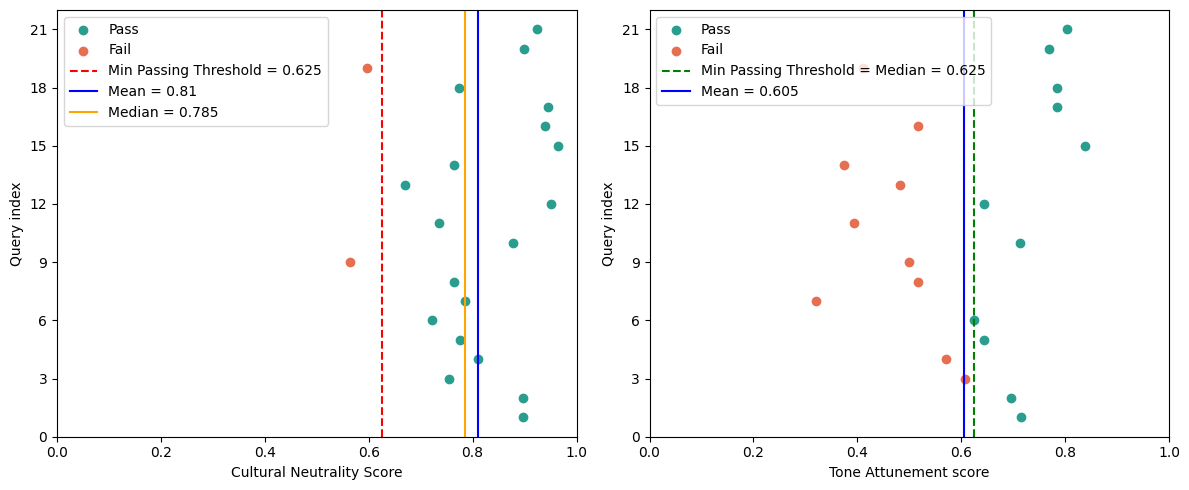

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Cultural Neutrality
ax1.scatter(cn_scores[cn_scores >= 0.625],
            [i for i, s in enumerate(cn_scores, 1) if s >= 0.625],
            c='#2a9d8f', label='Pass')
ax1.scatter(cn_scores[cn_scores < 0.625],
            [i for i, s in enumerate(cn_scores, 1) if s < 0.625],
            c='#e76f51', label='Fail')
ax1.axvline(0.625, color='red', linestyle='--', label='Min Passing Threshold = 0.625')
ax1.axvline(0.81, color='blue', linestyle='-', label='Mean = 0.81')
ax1.axvline(0.785, color='orange', linestyle='-', label='Median = 0.785')
ax1.set_xlim(0, 1)
ax1.set_xlabel('Cultural Neutrality Score')
ax1.set_ylabel('Query index')
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
ax1.legend()

# Tone Attunement
ax2.scatter(ta_scores[ta_scores >= 0.625],
            [i for i, s in enumerate(ta_scores, 1) if s >= 0.625],
            c='#2a9d8f', label='Pass')
ax2.scatter(ta_scores[ta_scores < 0.625],
            [i for i, s in enumerate(ta_scores, 1) if s < 0.625],
            c='#e76f51', label='Fail')
ax2.axvline(0.625, color='green', linestyle='--', label='Min Passing Threshold = Median = 0.625')
ax2.axvline(0.605, color='blue', linestyle='-', label='Mean = 0.605')
ax2.set_xlim(0, 1)
ax2.set_xlabel('Tone Attunement score')
ax2.set_ylabel('Query index')
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
ax2.legend()

plt.tight_layout()
plt.show()

----

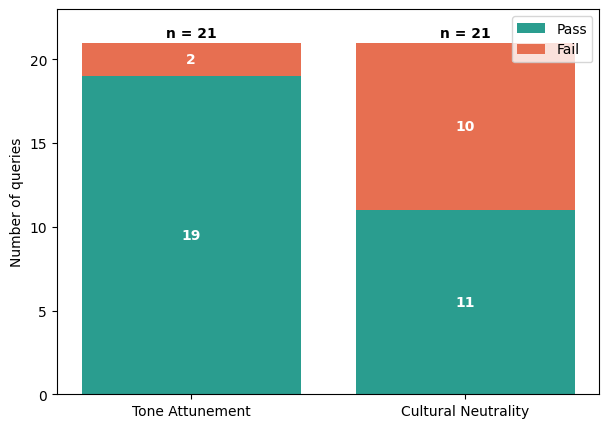

In [10]:
metrics = ['Tone Attunement', 'Cultural Neutrality']
passes = [(annot_scores['CN_score'] >= 0.625).sum(), (annot_scores['TA_score'] >= 0.625).sum()]
fails = [(annot_scores['CN_score'] < 0.625).sum(), (annot_scores['TA_score'] < 0.625).sum()]
ns = [len(annot_scores['CN_score']), len(annot_scores['TA_score'])]

plt.figure(figsize=(7, 5))
plt.bar(metrics, passes, color='#2a9d8f', label='Pass')
plt.bar(metrics, fails, bottom=passes, color='#e76f51', label='Fail')

# n labels above each bar
for i, n in enumerate(ns):
    plt.text(i, n + 0.3, f'n = {n}', ha='center', fontweight='bold')

# pass/fail counts inside the bar segments
for i, (p, fl) in enumerate(zip(passes, fails)):
    if p > 0:
        plt.text(i, p/2, str(p), ha='center', va='center', color='white', fontweight='bold')
    if fl > 0:
        plt.text(i, p + fl/2, str(fl), ha='center', va='center', color='white', fontweight='bold')

plt.ylabel('Number of queries')
plt.ylim(0, max(ns) + 2)
plt.legend()
plt.show()

## Dataset B

In [ ]:
tech_annot = pd.read_csv('../data/qa_pairs_annotated.csv')
tech_annot.head()

,user_input,bot_output,context,answer_relevancy_label,context_relevancy_label,faithfulness_label
0,I don't have a place to stay because I escaped...,I'm really sorry to hear about your situation....,[],1,NaN,NaN
1,"I am running away from my abuser, who is searc...",I'm really sorry to hear that you're in this s...,[],1,NaN,NaN
2,"I need help because I am in danger, but I do n...",I'm really sorry to hear that you're in danger...,[],1,NaN,NaN
3,"I have been to 3 hospitals, but they refuse me...","Hello, I am Aidly, the HIA chatbot.\n\nIf you ...","[""Document: Remaining Undocumented If you rema...",1,0.0,1.0
4,I need a doctor.,"Hello! I'm Aidly, the HIA chatbot. I can help ...",[],1,NaN,NaN


In [90]:
ar = tech_annot['answer_relevancy_label']
cr = tech_annot['context_relevancy_label'].dropna().reset_index(drop=True)
f = tech_annot['faithfulness_label'].dropna().reset_index(drop=True)

In [91]:
# for human-annotated set
ar_scores = np.array(ar)
cr_scores = np.array(cr)
f_scores = np.array(f)
print(
    "Answer Relevancy:",
    f"\nTotal rows: {len(ar_scores)}"
    f"\nmean: {np.mean(ar_scores):.3f}",
    f"\nmedian: {np.median(ar_scores):.3f}",
    f"\nmin: {np.min(ar_scores):.3f}",
    f"\nmax: {np.max(ar_scores):.3f}",
    "\n"
    "\nContext Relevancy:",
    f"\nTotal rows: {len(cr_scores)}"
    f"\nmean: {np.mean(cr_scores):.3f}",
    f"\nmedian: {np.median(cr_scores):.3f}",
    f"\nmin: {np.min(cr_scores):.3f}",
    f"\nmax: {np.max(cr_scores):.3f}",
    "\n"
    "\nFaithfulness:",
    f"\nTotal rows: {len(f_scores)}"
    f"\nmean: {np.mean(f_scores):.3f}",
    f"\nmedian: {np.median(f_scores):.3f}",
    f"\nmin: {np.min(f_scores):.3f}",
    f"\nmax: {np.max(f_scores):.3f}",
)

Answer Relevancy: 
Total rows: 21
mean: 0.952 
median: 1.000 
min: 0.000 
max: 1.000 

Context Relevancy: 
Total rows: 13
mean: 0.154 
median: 0.000 
min: 0.000 
max: 1.000 

Faithfulness: 
Total rows: 13
mean: 0.923 
median: 1.000 
min: 0.000 
max: 1.000

In [92]:
print(
  f'Pass rate for AR manual labelling output: {(ar_scores >= 0.75).mean():.3f}',
  f'\nPass rate for CR manual labelling output: {(cr_scores >= 0.86).mean():.3f}',
  f'\nPass rate for F manual labelling output: {(f_scores >= 0.85).mean():.3f}'
)

Pass rate for AR manual labelling output: 0.952 
Pass rate for CR manual labelling output: 0.154 
Pass rate for F manual labelling output: 0.923

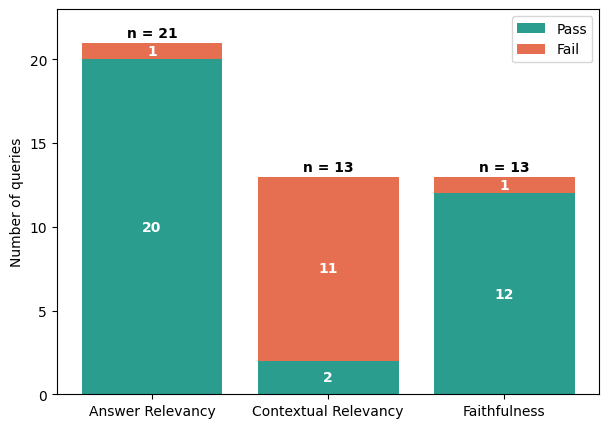

In [15]:
ar = tech_annot['answer_relevancy_label']
cr = tech_annot['context_relevancy_label'].dropna().reset_index(drop=True)
f = tech_annot['faithfulness_label'].dropna().reset_index(drop=True)

metrics = ['Answer Relevancy', 'Contextual Relevancy', 'Faithfulness']
passes = [(ar == 1).sum(), (cr == 1).sum(), (f == 1).sum()]
fails = [(ar == 0).sum(), (cr == 0).sum(), (f == 0).sum()]
ns = [len(ar), len(cr), len(f)]

plt.figure(figsize=(7, 5))
plt.bar(metrics, passes, color='#2a9d8f', label='Pass')
plt.bar(metrics, fails, bottom=passes, color='#e76f51', label='Fail')

# n labels above each bar
for i, n in enumerate(ns):
    plt.text(i, n + 0.3, f'n = {n}', ha='center', fontweight='bold')

# pass/fail counts inside the bar segments
for i, (p, fl) in enumerate(zip(passes, fails)):
    if p > 0:
        plt.text(i, p/2, str(p), ha='center', va='center', color='white', fontweight='bold')
    if fl > 0:
        plt.text(i, p + fl/2, str(fl), ha='center', va='center', color='white', fontweight='bold')

plt.ylabel('Number of queries')
plt.ylim(0, max(ns) + 2)
plt.legend()
plt.show()

In [16]:
data = pd.read_csv("../data/goldens_final.csv", encoding='utf-8-sig')

# Client setup
load_dotenv()
key = os.getenv("azure_subscription_key")
api_version = "2024-12-01-preview"

endpoint = "https://510-ai-research.cognitiveservices.azure.com/"
model_name = "text-embedding-3-small"
deployment = "text-embedding-3-small"

client = AzureOpenAI(
    api_version=api_version,
    azure_endpoint=endpoint,
    api_key=key,
)

# Batch embedding
def embed_texts(texts, batch_size=50):
  """Embed a list of strings."""
  all_vectors = []
  for i in range(0, len(texts), batch_size):
      batch = texts[i : i + batch_size]
      response = client.embeddings.create(input=batch, model=deployment)
      all_vectors.extend([item.embedding for item in response.data])
  return np.array(all_vectors)

# aggregate a context (list of chunks) to one vector
def embed_context(chunks):
  """Mean-pool embeddings of all chunks in one context."""
  vectors = embed_texts(chunks)
  return vectors.mean(axis=0)

# cosine between two vectors
def cosine(vec_a, vec_b):
    """Cosine similarity between two 1D vectors. Returns a float."""
    return cosine_similarity(vec_a.reshape(1, -1), vec_b.reshape(1, -1))[0, 0]

# For CR
cr_cos = []
for i in range(len(data)):
    inp_vec = embed_texts([data['user_input'][i]])[0]
    exp_vec = embed_context(ast.literal_eval(data['context'][i]))
    cr_cos.append(cosine(inp_vec, exp_vec))

# For F
f_cos = []
for i in range(len(data)):
    inp_vec = embed_texts([data['expected_output'][i]])[0]
    exp_vec = embed_context(ast.literal_eval(data['context'][i]))
    f_cos.append(cosine(inp_vec, exp_vec))

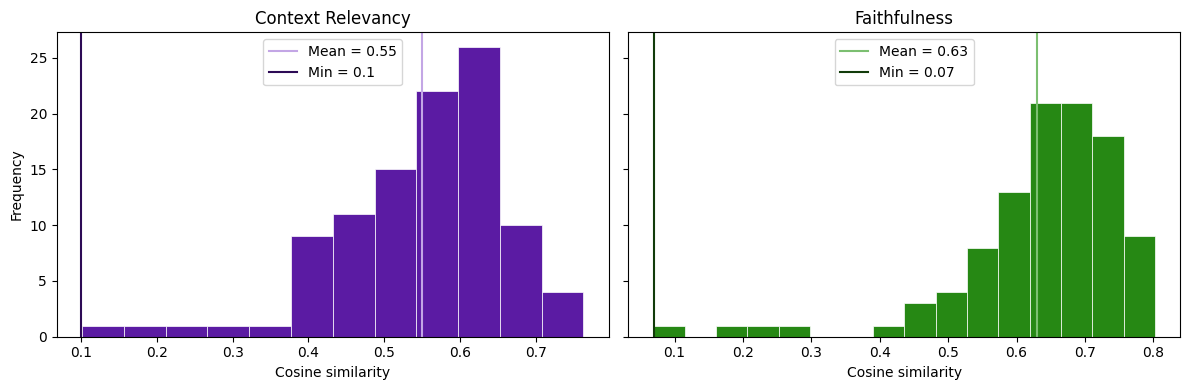

In [113]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.hist(cr_cos, bins='auto', linewidth=0.5, edgecolor="white", color="#5b1ba3")
ax1.set_title('Context Relevancy')
ax1.axvline(0.55, color="#c3a6e5", label='Mean = 0.55')
ax1.axvline(0.1, color="#2d0a55", label='Min = 0.1')
ax1.set_xlabel('Cosine similarity')
ax1.set_ylabel('Frequency')
ax1.legend()

ax2.hist(f_cos, bins='auto', linewidth=0.5, edgecolor="white", color="#268814")
ax2.axvline(0.63, color="#7CBF71", label='Mean = 0.63')
ax2.axvline(0.07, color="#123B0A", label='Min = 0.07')
ax2.set_title('Faithfulness')
ax2.set_xlabel('Cosine similarity')
ax2.legend()

plt.tight_layout()
plt.show()

# Framework Outputs

## Humanitarian Metrics

In [17]:
human_eval = pd.read_csv('../data/evaluation_results.csv')
human_eval.head()

,conv_id,user_input,bot_output,retrieval_context,Answer Relevancy,Answer Relevancy Reason,Faithfulness,Faithfulness Reason,Contextual Relevancy,Contextual Relevancy Reason,Tone Attunement [GEval],Tone Attunement [GEval] Reason,Cultural Neutrality [GEval],Cultural Neutrality [GEval] Reason
0,b741fc96-b332-444d-be62-18630b90891b,I need a doctor.,"Hello! I'm Aidly, the HIA chatbot. I can help ...",[],0.750000,The score is 0.75 because while the output par...,1.0,The score is 1.00 because there are no contrad...,0.000000,The score is 0.00 because there are no relevan...,0.7,"The user's input is brief and urgent, suggesti...",1.0,The response does not assume any user characte...
1,aafba393-11f1-4ab0-b40a-49105373042e,I don't have a place to stay because I escaped...,I'm really sorry to hear about your situation....,[],1.000000,Great job! The score is 1.00 because every par...,1.0,The score is 1.00 because there are no contrad...,0.000000,The score is 0.00 because there are no relevan...,1.0,The Input expresses distress and vulnerability...,1.0,The response expresses empathy and provides ne...
2,1db6b4d5-f55b-4286-9422-827f41e69613,"I need help because I am in danger, but I do n...",I'm really sorry to hear that you're in danger...,[],1.000000,Great job! The score is 1.00 because the respo...,1.0,The score is 1.00 because there are no contrad...,0.000000,The score is 0.00 because there are no relevan...,1.0,"The Input expresses fear and vulnerability, in...",1.0,The response does not make assumptions about t...
3,0cb54ff2-70c9-4532-ae0f-888c8b9d0ebf,"I am running away from my abuser, who is searc...",I'm really sorry to hear that you're in this s...,[],1.000000,Great job! The score is 1.00 because the respo...,1.0,The score is 1.00 because there are no contrad...,0.000000,The score is 0.00 because there are no relevan...,1.0,The user's input expresses fear and distress i...,1.0,"The output is empathetic, neutral, and inclusi..."
4,be9e2ab4-86d5-4585-a9c2-c0b1f7ef9acf,"I have been to 3 hospitals, but they refuse me...","Hello, I am Aidly, the HIA chatbot.\n\nIf you ...",['Document: Remaining Undocumented If you rema...,0.923077,The score is 0.92 because the response was mos...,1.0,The score is 1.00 because there are no contrad...,0.466667,"The score is 0.47 because, although there are ...",0.9,"The user's input is urgent, distressed, and vu...",1.0,The response does not make assumptions about t...


In [ ]:
# for DE results
cn_scores = np.array(human_eval['Cultural Neutrality [GEval]'])
ta_scores = np.array(human_eval['Tone Attunement [GEval]'])
print(
    "Cultural Neutrality:",
    f"\nmean: {np.mean(cn_scores):.3f}",
    f"\nmedian: {np.median(cn_scores):.3f}",
    f"\nmin: {np.min(cn_scores):.3f}",
    f"\nmax: {np.max(cn_scores):.3f}",
    "\n"
    "\nTone Attunement:",
    f"\nmean: {np.mean(ta_scores):.3f}",
    f"\nmedian: {np.median(ta_scores):.3f}",
    f"\nmin: {np.min(ta_scores):.3f}",
    f"\nmax: {np.max(ta_scores):.3f}",
)

Cultural Neutrality: 
mean: 0.957 
median: 1.000 
min: 0.700 
max: 1.000 

Tone Attunement: 
mean: 0.805 
median: 0.800 
min: 0.200 
max: 1.000

CN scores sit very high (between 0.7 and 1.00), while TA scores are more evenly distributed (between 0.2 and 1.00).

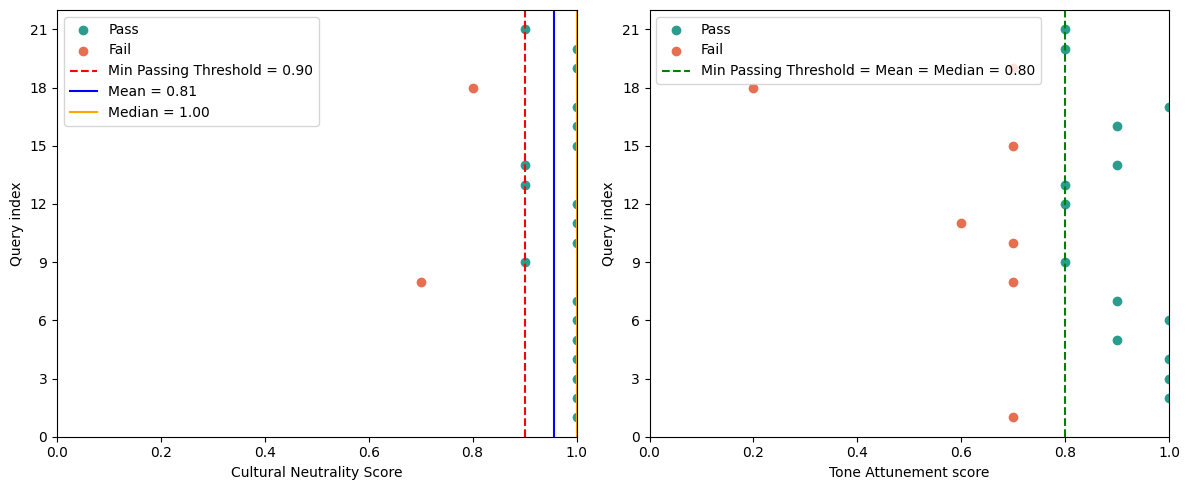

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Cultural Neutrality
ax1.scatter(cn_scores[cn_scores >= 0.90],
            [i for i, s in enumerate(cn_scores, 1) if s >= 0.90],
            c='#2a9d8f', label='Pass')
ax1.scatter(cn_scores[cn_scores < 0.90],
            [i for i, s in enumerate(cn_scores, 1) if s < 0.90],
            c='#e76f51', label='Fail')
ax1.axvline(0.90, color='red', linestyle='--', label='Min Passing Threshold = 0.90')
ax1.axvline(0.957, color='blue', linestyle='-', label='Mean = 0.81')
ax1.axvline(1.00, color='orange', linestyle='-', label='Median = 1.00')
ax1.set_xlim(0, 1)
ax1.set_xlabel('Cultural Neutrality Score')
ax1.set_ylabel('Query index')
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
ax1.legend()

# Tone Attunement
ax2.scatter(ta_scores[ta_scores >= 0.80],
            [i for i, s in enumerate(ta_scores, 1) if s >= 0.80],
            c='#2a9d8f', label='Pass')
ax2.scatter(ta_scores[ta_scores < 0.80],
            [i for i, s in enumerate(ta_scores, 1) if s < 0.80],
            c='#e76f51', label='Fail')
ax2.axvline(0.80, color='green', linestyle='--', label='Min Passing Threshold = Mean = Median = 0.80')
ax2.set_xlim(0, 1)
ax2.set_xlabel('Tone Attunement score')
ax2.set_ylabel('Query index')
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
ax2.legend()

plt.tight_layout()
plt.show()

We have what looks like a couple of outliers in both metric plots. For CN, they sit at or below 0.8. For TA, there is only one positioned at 0.2.

In [20]:
pd.set_option('display.max_colwidth', None)

In [ ]:
cn_outliers = human_eval[human_eval['Cultural Neutrality [GEval]'] <= 0.8]
ta_outliers = human_eval[human_eval['Tone Attunement [GEval]'] < 0.4]
print(
    f'CN outliers:\n{cn_outliers[['user_input', 'bot_output', 'Cultural Neutrality [GEval]']]}',
f'\nTA outliers:\n{ta_outliers[['user_input', 'bot_output', 'Tone Attunement [GEval]']]}'
)

CN outliers:
                                                                                user_input  \
7   live in Utrecht, but I got kicked out of my house today. Where can I find a warm meal?   
17                                                      wer find winter clodes. I nigeria.   

                                                                                                                   
                                                                                                                   
                                                                                                                   
                                                                                                                   
                                                                     bot_output  \
7   Hello! If you are staying in a public shelter in Utrecht, please ask someone from the shelter where you can 
find additional food support. You can also contact the Red Cross Food Program Helpdesk for assistance. 
Additionally, the Food Bank Netherlands (Voedselbank Nederland) distributes food parcels to displaced persons from 
Ukraine across the country. You can check your eligibility and find more information here: 
https://voedselbankennederland.nl/vertalingen/english/\n\nIf you need more specific local support, please let me 
know!   
17                                                                                                                 
I don't have the right information to answer your question.   

    Cultural Neutrality [GEval]  
7                           0.7  
17                          0.8   
TA outliers:
                            user_input  \
17  wer find winter clodes. I nigeria.   

                                                     bot_output  \
17  I don't have the right information to answer your question.   

    Tone Attunement [GEval]  
17                      0.2

After closer inspection, for CN the cases are not outliers (scores are too close to the mean to be considered outliers). As for TA, the query is specifically designed to stress-test the metric, which it successfully does.

Degenerate distribution: Most values for CN sit at 0.9 or 1.00.

In [ ]:
print(
    f'Number of queries where CN = 0.9: {len(human_eval[human_eval['Cultural Neutrality [GEval]'] == 0.9])}',
    f'\nNumber of queries where CN = 1.00: {len(human_eval[human_eval['Cultural Neutrality [GEval]'] == 1.00])}'
)

Number of queries where CN = 0.9: 4 
Number of queries where CN = 1.00: 15

----

In [ ]:
ar = tech_annot['answer_relevancy_label']
cr = tech_annot['context_relevancy_label'].dropna().reset_index(drop=True)
f = tech_annot['faithfulness_label'].dropna().reset_index(drop=True)

In [ ]:
print(
  f'Pass rate for CN framework output: {(cn_scores >= 0.90).mean():.3f}',
  f'\nPass rate for TA framework output: {(ta_scores >= 0.80).mean():.3f}'
)

Pass rate for CN framework output: 0.905 
Pass rate for TA framework output: 0.667

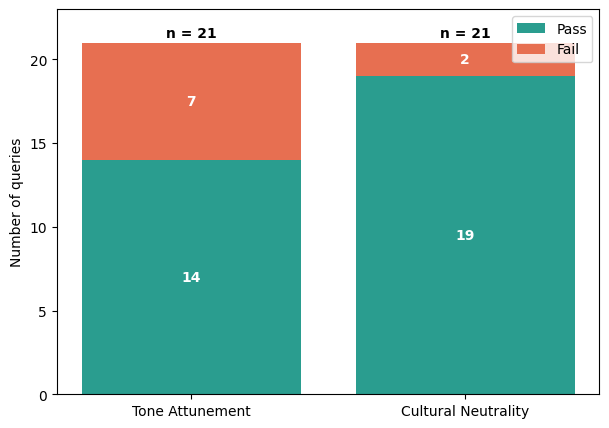

In [ ]:
metrics = ['Tone Attunement', 'Cultural Neutrality']
passes = [(human_eval['Tone Attunement [GEval]'] >= 0.8).sum(), (human_eval['Cultural Neutrality [GEval]'] >= 0.9).sum()]
fails = [(human_eval['Tone Attunement [GEval]'] < 0.8).sum(), (human_eval['Cultural Neutrality [GEval]'] < 0.9).sum()]
ns = [len(human_eval['Tone Attunement [GEval]']), len(human_eval['Tone Attunement [GEval]'])]

plt.figure(figsize=(7, 5))
plt.bar(metrics, passes, color='#2a9d8f', label='Pass')
plt.bar(metrics, fails, bottom=passes, color='#e76f51', label='Fail')

# n labels above each bar
for i, n in enumerate(ns):
    plt.text(i, n + 0.3, f'n = {n}', ha='center', fontweight='bold')

# pass/fail counts inside the bar segments
for i, (p, fl) in enumerate(zip(passes, fails)):
    if p > 0:
        plt.text(i, p/2, str(p), ha='center', va='center', color='white', fontweight='bold')
    if fl > 0:
        plt.text(i, p + fl/2, str(fl), ha='center', va='center', color='white', fontweight='bold')

plt.ylabel('Number of queries')
plt.ylim(0, max(ns) + 2)
plt.legend()
plt.show()

----

In [ ]:
cn_outliers = human_eval[human_eval['user_input'].str.contains("Morocco", na=False)]
print(
    f'CN outliers:\n{cn_outliers[["Cultural Neutrality [GEval]"]]}',
)

CN outliers:
    Cultural Neutrality [GEval]
13                          0.9

## Technical Metrics

In [137]:
ar = human_eval['Answer Relevancy']
cr = human_eval['Contextual Relevancy'].dropna().reset_index(drop=True)
f = human_eval['Faithfulness'].dropna().reset_index(drop=True)

ar_scores = np.array(ar)
cr_scores = np.array(cr)
f_scores = np.array(f)

print(
    "Answer Relevancy:",
    f"\nmean: {np.mean(ar_scores):.3f}",
    f"\nmedian: {np.median(ar_scores):.3f}",
    f"\nmin: {np.min(ar_scores):.3f}",
    f"\nmax: {np.max(ar_scores):.3f}",
    f'\nlen: {len(ar)}'
    "\n"
    "\nContextual Relevancy:",
    f"\nmean: {np.mean(cr_scores):.3f}",
    f"\nmedian: {np.median(cr_scores):.3f}",
    f"\nmin: {np.min(cr_scores):.3f}",
    f"\nmax: {np.max(cr_scores):.3f}",
    f'\nlen: {len(cr)}'
    "\n"
    "\nFaithfulness:",
    f"\nmean: {np.mean(f_scores):.3f}",
    f"\nmedian: {np.median(f_scores):.3f}",
    f"\nmin: {np.min(f_scores):.3f}",
    f"\nmax: {np.max(f_scores):.3f}",
    f'\nlen: {len(f)}'
)

Answer Relevancy: 
mean: 0.857 
median: 0.923 
min: 0.000 
max: 1.000 
len: 21

Contextual Relevancy: 
mean: 0.263 
median: 0.223 
min: 0.000 
max: 0.835 
len: 21

Faithfulness: 
mean: 0.995 
median: 1.000 
min: 0.889 
max: 1.000 
len: 21

In [52]:
print(
  f'Pass rate for AR framework output: {(ar_scores >= 0.75).mean():.3f}',
  f'\nPass rate for CR framework output: {(cr_scores >= 0.86).mean():.3f}',
  f'\nPass rate for F framework output: {(f_scores >= 0.85).mean():.3f}'
)

Pass rate for AR framework output: 0.857 
Pass rate for CR framework output: 0.000 
Pass rate for F framework output: 1.000

Answer Relevancy

In [70]:
# How many perfectly scored rows do we have?
print(len(human_eval[ar == 1.0]))

9

In [73]:
# Percentage of data points which received perfect scores
print(f"{9/21:.3f}")

0.429

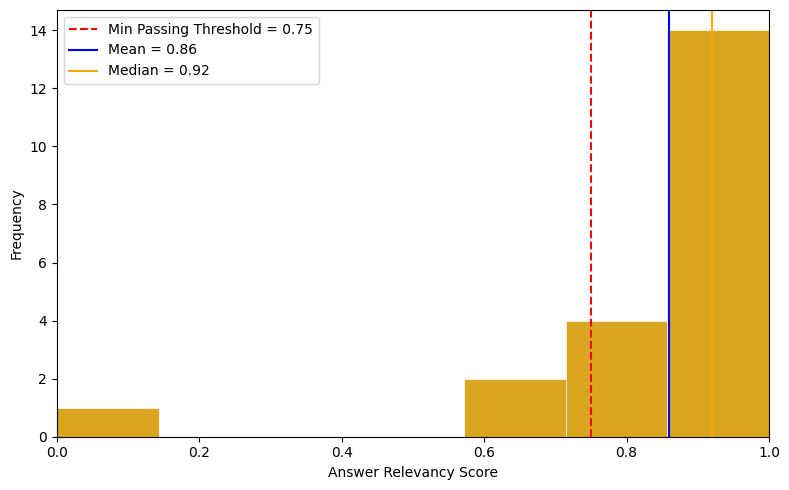

In [138]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(ar_scores, bins='auto', range=(0, 1),
        color='#daa520', edgecolor='white', linewidth=0.5)
ax.axvline(0.75, color='red', linestyle='--', label='Min Passing Threshold = 0.75')
ax.axvline(0.86 , color='blue', linestyle='-', label='Mean = 0.86')
ax.axvline(0.92, color='orange', linestyle='-', label='Median = 0.92')
ax.set_xlim(0, 1)
ax.set_xlabel('Answer Relevancy Score')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

In [88]:
# Seems like most values sit between [0.9, 1.00]
print(len(human_eval[(ar >= 0.9) & (ar <= 1.00)]))

13

We have one outlier. Let's inspect.

In [62]:
ar_outliers = human_eval[ar < 0.6]
print(
    f'AR outliers:\n{ar_outliers[['user_input', 'bot_output', 'Answer Relevancy']]}'
)

AR outliers:
                            user_input  \
17  wer find winter clodes. I nigeria.   

                                                     bot_output  \
17  I don't have the right information to answer your question.   

    Answer Relevancy  
17               0.0

The answer is irrelevant to the query because the chatbot cannot answer. Framework is correct for flagging this.

Context Relevancy

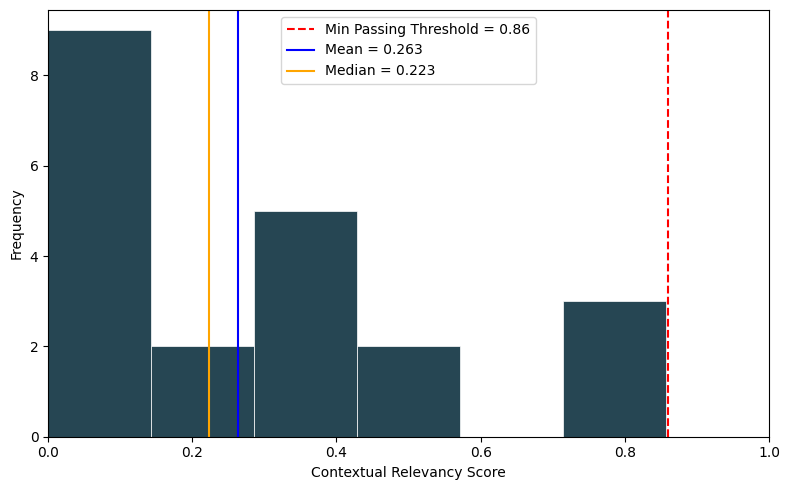

In [141]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(cr_scores, bins='auto', range=(0, 1),
        color='#264653', edgecolor='white', linewidth=0.5)
ax.axvline(0.86, color='red', linestyle='--', label='Min Passing Threshold = 0.86')
ax.axvline(0.263, color='blue', linestyle='-', label='Mean = 0.263')
ax.axvline(0.223, color='orange', linestyle='-', label='Median = 0.223')
ax.set_xlim(0, 1)
ax.set_xlabel('Contextual Relevancy Score')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

There are a lot of values with a very low CR score (<= 0.2). There are also no values that pass the set threshold.

In [67]:
# How many values have a very low scores?
print(len(human_eval[cr <= 0.2]))

10

In [77]:
# How many data points score less than 0.5 CR?
print(len(human_eval[cr <= 0.5]),
      f'\nPercentage of data which scores < 0.5 CR: {18/21:.3f}')

18 
Percentage of data which scores < 0.5 CR: 0.857

Faithfulness

In [68]:
# How many data points receive a perfect F score?
print(len(human_eval[f == 1.00]))

20

In [87]:
# Which data point received less than a pefect score?
f_value = human_eval[f < 1.00]
print(
    f'Only row with F < 1.00:\n{f_value[['Faithfulness', 'Faithfulness Reason','user_input','bot_output']]}',
    f'\n{f_value['retrieval_context']}'
)

Only row with F < 1.00:
    Faithfulness  \
14      0.888889   

                                                                                                                   
                                                                                                                   
 Faithfulness Reason  \
14  The score is 0.89 because the actual output incorrectly claims that the AI can help find specific contacts or 
locations for food or medical support, which is not stated in the retrieval context. Otherwise, the output aligns 
well with the context.   

                                                                                                                   
                                                                user_input  \
14  I have diabetes and I am undocumented. I need insulin but I also cannot afford the food I need for my diet. The
doctor told me I need to eat differently but everything is too expensive.   

                                                                                                                   
                                                                                                                   
                                                                                                                   
                                                                                                                   
                                                                                                                   
                                                                                                                   
                                                                                                                   
                                                                                                                   
                                                                                                                   
                                                                                           bot_output  
14  I'm sorry to hear about your situation. For food support, you can contact the Red Cross Food Program Helpdesk 
for assistance. They can provide information on where to find additional food support, especially if you are 
staying in a public shelter. You can reach them by call, text, or WhatsApp at +31 97010259797 (Monday to Friday, 
9:00 – 17:00).\n\nAlso, in many municipalities, Voedselbank Nederland (Food Bank Netherlands) distributes food 
parcels to displaced persons from Ukraine. You can check your eligibility here: 
https://voedselbankennederland.nl/vertalingen/english/\n\nRegarding your medical needs, the Dutch Red Cross can 
provide general information about healthcare but does not offer direct medical assistance. For insulin and diabetes
care, you might want to contact local healthcare providers or your municipality's health services.\n\nIf you are 
staying with a host family and have dietary needs, you can discuss with your host about cooking some meals yourself
or using social money to buy the food you need.\n\nIf you want, I can help you find specific contacts or locations 
near you for food or medical support.   
14    ['Document: Food support per city The Red Cross Helpful Information website provides an overview of food 
options available in different cities.\n\nYou can always refer the PA to this website or share the list of options 
found there directly.  https://helpfulinformation.redcross.nl/', "Document: How can I get food support?  \n\nWhen 
you are staying in a public shelter, please approach someone from the shelter to ask where you can find additional 
food support.\n\nYou can also contact the Red Cross Food Program Helpdesk.\n\nFor all general questions, new 
applications, extension requests, etc, PA's can call/text/\n\nWhatsApp them at +31 97010259797 (Mon-Fri 9:00 – 
17:00).  \n\nIn municipalities all over the country Voeds

In [116]:
no_context = human_eval[human_eval['retrieval_context'] == '[]']
print(len(no_context))

8

Only one data point scores below 1.00 because the AI states it can help with finding a specific location or contacts for help with food, which is not specifically mentioned in the retrieval context. While the framework is correct to flag this, the AI is not incorrect to offer help for this as the chatbot can help individuals find shelter/ food bank locations based on their location.

In [119]:
context_rows = human_eval[human_eval['retrieval_context'] != '[]']
with_context = context_rows['Faithfulness']
wc_scores = np.array(with_context)
print(f'Pass rate for F for rows with retrieved contexts: {(wc_scores >= 0.85).mean():.3f}')

Pass rate for F for rows with retrieved contexts: 1.000

### Task Completion Rate (latency)

In [97]:
d = pd.read_csv('../data/evaluation_results_latency.csv')
latency = d['latency']

In [96]:
lat_scores = np.array(latency)
print(f'Pass rate for TCR: {(lat_scores <= 7.46).mean():.3f}')

Pass rate for TCR: 0.952

In [98]:
print(
    "Task Completion Rate:",
    f"\nmean: {np.mean(lat_scores):.3f}",
    f"\nmedian: {np.median(lat_scores):.3f}",
    f"\nmin: {np.min(lat_scores):.3f}",
    f"\nmax: {np.max(lat_scores):.3f}",
    f'\nlen: {len(latency)}'
)

Task Completion Rate: 
mean: 4.481 
median: 4.613 
min: 1.980 
max: 8.709 
len: 21

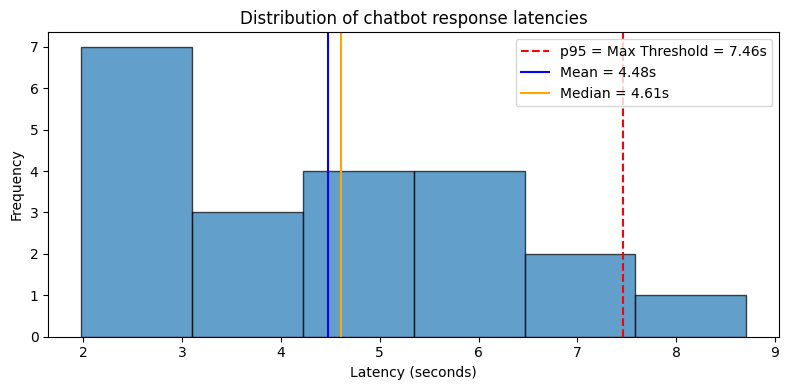

In [123]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lat_scores, bins='auto', edgecolor='black', alpha=0.7)
ax.axvline(7.46, color='red', linestyle='--', label='p95 = Max Threshold = 7.46s')
ax.axvline(4.48 , color='blue', linestyle='-', label='Mean = 4.48s')
ax.axvline(4.61, color='orange', linestyle='-', label='Median = 4.61s')
ax.set_xlabel('Latency (seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of chatbot response latencies')
ax.legend()
plt.tight_layout()
plt.show()

In [126]:
print(f'Number of values between 2 and 3: {len(latency[(latency >= 2) & (latency <= 3.5)])}')

Number of values between 2 and 3: 7

In [124]:
print(f'Number of values between 4 and 6: {len(latency[(latency >= 4) & (latency <= 6)])}')

Number of values between 4 and 6: 8

----

# Discussion - Supplementary

In [183]:
# Is latency lower for the rows that did not retrieve contexts?
context = d[d['retrieval_context'] != '[]']
lat_context = context['latency'].mean()

no_context = d[d['retrieval_context'] == '[]']
lat_no_context = no_context['latency'].mean()
print(
    f'Latency for rows with context:{lat_context:.3f} vs. without context {lat_no_context:.3f}'
)

Latency for rows with context:4.346 vs. without context 4.661